# Descriptive Baseline

In [64]:
import pandas as pd 
import numpy as np 
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_parquet("../data/processed/features.parquet")

In [ ]:
## Overall churn rate
churn_rate = round(data['Churn_binary'].mean()*100,2)
print("Overall churn rate is: ",churn_rate, "%")


Overall churn rate is:  26.54 %


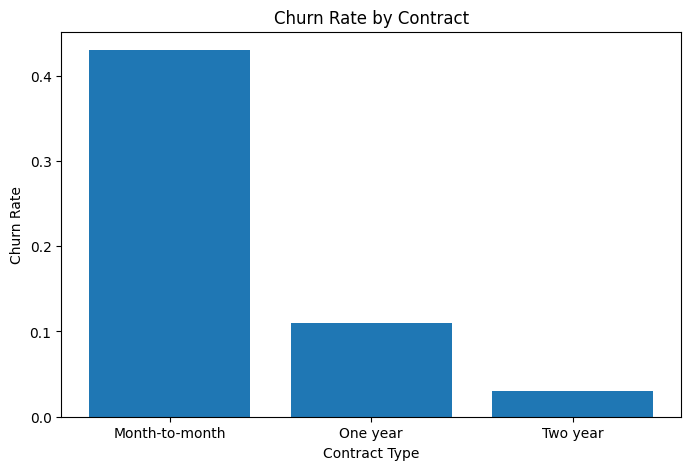

In [65]:

## Churn by contract type
churn_by_contract = round(data.groupby('Contract')['Churn_binary'].mean(),2)

plt.figure(figsize=(8,5))
plt.bar(churn_by_contract.index, churn_by_contract.values)
plt.title("Churn Rate by Contract")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.show()

C:\Users\Tejali\AppData\Local\Temp\ipykernel_14340\2697920713.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = round(data.groupby('tenure_band')['Churn_binary'].mean(),2)


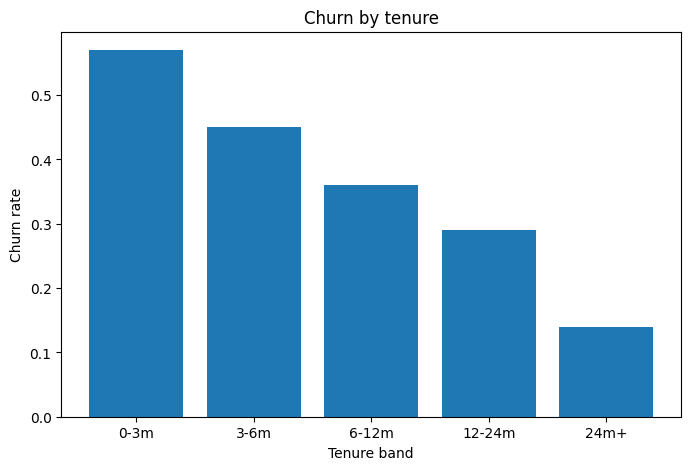

In [66]:
## Churn by tenure band
churn_by_tenure = round(data.groupby('tenure_band')['Churn_binary'].mean(),2)

plt.figure(figsize=(8,5))
plt.bar(churn_by_tenure.index, churn_by_tenure.values)
plt.title("Churn by tenure")
plt.xlabel("Tenure band")
plt.ylabel("Churn rate")
plt.show()


In [95]:
## Churn by monthly charges
data["charge_band"] = pd.cut(
    data["MonthlyCharges"],
    bins=[0, 20, 40, 60, 80, 100, 120],
    labels=["0-20", "20-40", "40-60", "60-80", "80-100", "100-120"]
)
churn_by_monthly_charges = round(data.groupby('charge_band')['Churn_binary'].mean(),2)
churn_by_monthly_charges


C:\Users\Tejali\AppData\Local\Temp\ipykernel_14340\2047002575.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_monthly_charges = round(data.groupby('charge_band')['Churn_binary'].mean(),2)


charge_band
0-20       0.09
20-40      0.13
40-60      0.26
60-80      0.32
80-100     0.37
100-120    0.28
Name: Churn_binary, dtype: float64

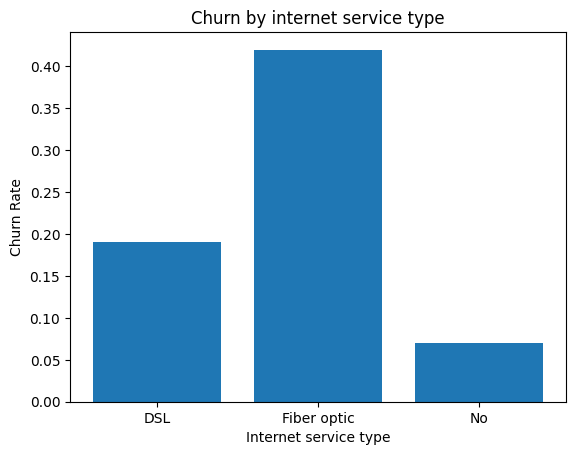

In [74]:
## Churn by internet service type
churn_by_internet_service = round(data.groupby('InternetService')['Churn_binary'].mean(),2)

plt.title("Churn by internet service type")
plt.bar(churn_by_internet_service.index, churn_by_internet_service.values)
plt.xlabel("Internet service type")
plt.ylabel("Churn Rate")
plt.show()


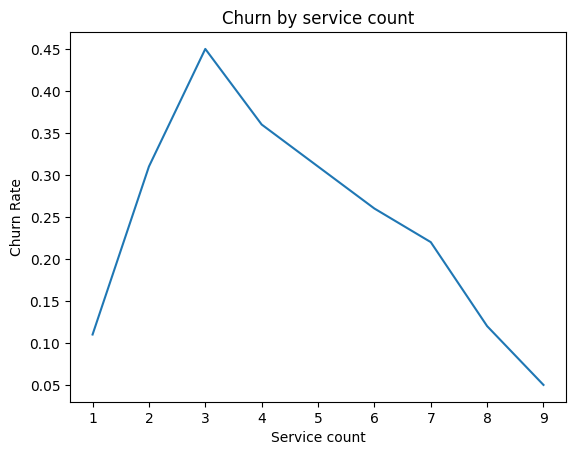

In [76]:
## Churn by service count
churn_by_service_count = round(data.groupby('service_count')['Churn_binary'].mean(),2)

plt.title("Churn by service count")
plt.plot(churn_by_service_count.index, churn_by_service_count.values)
plt.xlabel("Service count")
plt.ylabel("Churn Rate")
plt.show()

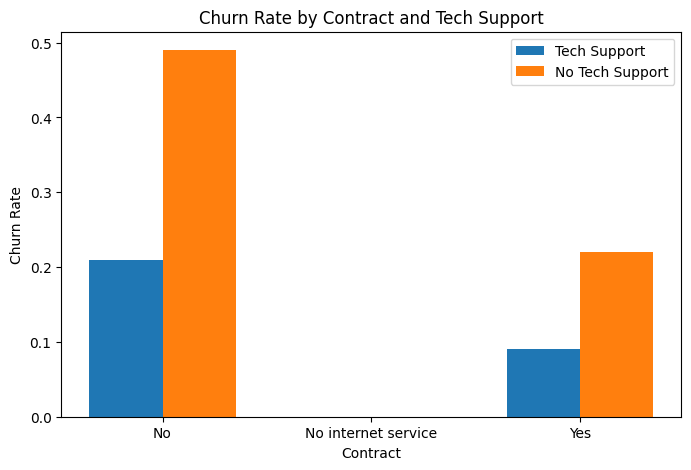

In [ ]:
## Churn by tech support and security
churn_tech_security = round(data.groupby(['TechSupport','OnlineSecurity'])['Churn_binary'].mean(),2).unstack()
x = np.arange(len(churn_tech_security.index))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, churn_tech_security["Yes"], width, label="Tech Support")
plt.bar(x + width/2, churn_tech_security["No"], width, label="No Tech Support")

plt.xticks(x, churn_tech_security.index)
plt.xlabel("Contract")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Contract and Tech Support")
plt.legend()

plt.show()

In [59]:
## Revenue at risk from churn rate
monthly_churn_rate = round(data['Churn_binary'].mean(),2)
avg_monthly_charges = round(data['MonthlyCharges'].mean(),2)
customer_count = data['customerID'].count()
revenue_at_risk = monthly_churn_rate * avg_monthly_charges * customer_count
print("Revenue at risk from churn rate: ", round(revenue_at_risk,2))

Revenue at risk from churn rate:  123148.26


## Key Findings

##### - Customers on month-to-month contracts exhibit the highest churn rate (over 40%), making contract type the strongest structural indicator for churn
##### - Churn is concentrated on the first six months of the customers's lifecycle, suggesting onboarding and early customer engagement would show retention opportuntiies
##### - Customers that chose Fiber Optics as their internet service type shows higher churn rate indicating - pricing strategies, dissatisfaction with the service or misalignment in expectations